/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [84 93] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Selected features: ['Operating_Gross_Margin', 'Realized_Sales_Gross_Margin', 'Cash_Turnover_Rate', 'Cash_Flow_to_Liability', 'Gross_Profit_to_Sales']
Balanced shape: (56, 6)
Cluster 5 Confusion Matrix:
 [[28  0]
 [ 0  1]]

Classification Report:
               precision    recall  f1-score   support

Not Bankrupt       1.00      1.00      1.00        28
    Bankrupt       1.00      1.00      1.00         1

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29


Base-model recall (TT/(TT+TF)):
  decision_tree   → recall = 1.00 [1(0)]
  svc             → recall = 1.00 [1(0)]
  knn             → recall = 1.00 [1(0)]
Total base-model recall = 1.00 [3(0)]


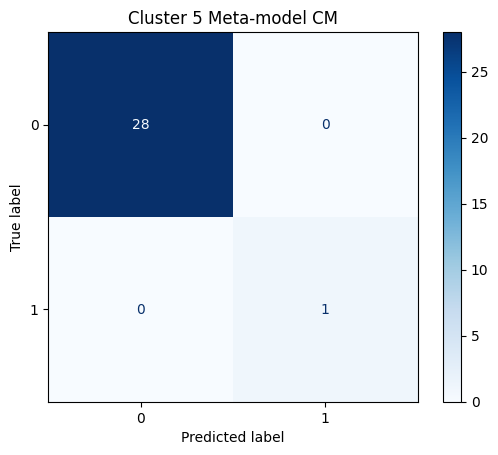

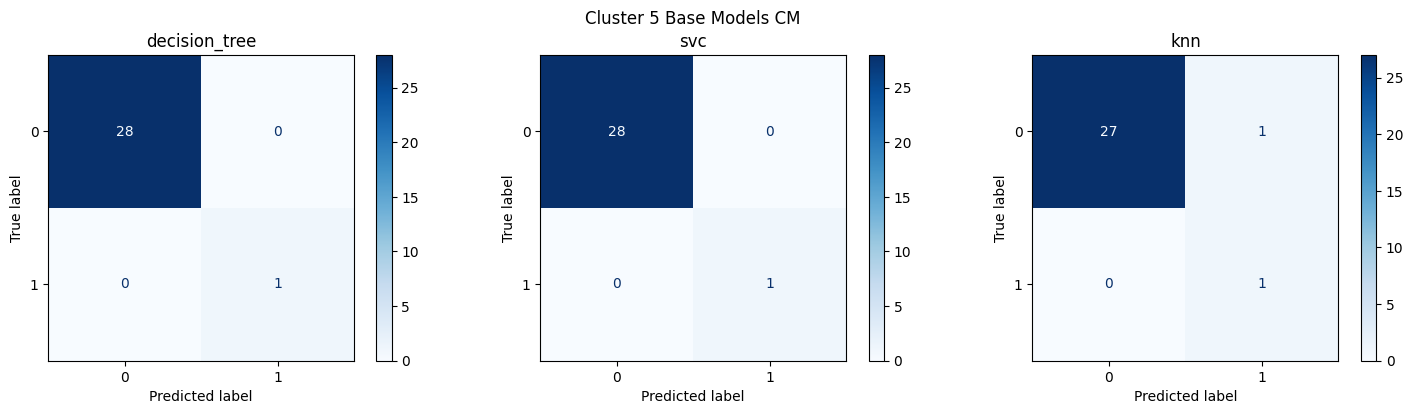


Saved scaler_cluster5.pkl and stacking_model_cluster5.pkl


In [ ]:
# Harshil_Chetankumar_Mode_Subgroup5.py

import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# 1) Load data
df = pd.read_csv('train_with_clusters.csv')
df.columns = df.columns.str.strip().str.replace(' ', '_')

# 2) Subset Cluster 5
cluster_id = 5
subgroup = df[df['ClusterID'] == cluster_id]
X = subgroup.drop(columns=['Index', 'ClusterID', 'Bankrupt?'])
y = subgroup['Bankrupt?']

# 3) Feature selection
k = 5
selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X, y)
selected_feats = X.columns[selector.get_support()]

# 4) Write selected features to txt
with open(f"selected_features_cluster{cluster_id}.txt", 'w') as f:
    for feat in selected_feats:
        f.write(f"{feat}\n")

print("Selected features:", list(selected_feats))

# 5) Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[selected_feats])

# 6) Balance with oversampling
df_scaled = pd.DataFrame(X_scaled, columns=selected_feats, index=X.index)
df_scaled['Bankrupt?'] = y.values
df_maj = df_scaled[df_scaled['Bankrupt?'] == 0]
df_min = df_scaled[df_scaled['Bankrupt?'] == 1]
df_min_up = resample(df_min,
                     replace=True,
                     n_samples=len(df_maj),
                     random_state=42)
df_bal = pd.concat([df_maj, df_min_up])
X_bal = df_bal[selected_feats].values
y_bal = df_bal['Bankrupt?'].values
print("Balanced shape:", df_bal.shape)

# 7) Define and train stacking model
base_models = [
    ('decision_tree', DecisionTreeClassifier(random_state=42)),
    ('svc',           SVC(kernel='poly', degree=3, probability=True, random_state=42)),
    ('knn',           KNeighborsClassifier()),
]
meta_model = MLPClassifier(max_iter=1000, random_state=42)
stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)
stacking.fit(X_bal, y_bal)

# 8) Evaluate stacked model
y_meta = stacking.predict(X_scaled)
cm = confusion_matrix(y, y_meta)
print("Cluster 5 Confusion Matrix:\n", cm)
print("\nClassification Report:\n",
      classification_report(y, y_meta, target_names=['Not Bankrupt','Bankrupt'], zero_division=0))

# === New Block: train & evaluate base models separately ===

# Train each base model on the balanced data
fitted_base_models = []
for name, model in base_models:
    model.fit(X_bal, y_bal)
    fitted_base_models.append((name, model))

# Predict and report each base model recall
tt_total = tf_total = 0
pred_base = {}
print("\nBase-model recall (TT/(TT+TF)):")
for name, model in fitted_base_models:
    y_pred = model.predict(X_scaled)
    pred_base[name] = y_pred
    tt = ((y == 1) & (y_pred == 1)).sum()
    tf = ((y == 1) & (y_pred == 0)).sum()
    tt_total += tt
    tf_total += tf
    recall = tt / (tt + tf) if tt + tf > 0 else 0.0
    print(f"  {name:15} → recall = {recall:.2f} [{tt}({tf})]")

total_recall = tt_total / (tt_total + tf_total)
print(f"Total base-model recall = {total_recall:.2f} [{tt_total}({tf_total})]")

# Plot confusion matrix for meta-model
disp_meta = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp_meta.plot(cmap='Blues')
plt.title(f'Cluster {cluster_id} Meta-model CM')
plt.show()

# Plot confusion matrices for base models
fig, axes = plt.subplots(1, len(fitted_base_models), figsize=(5 * len(fitted_base_models), 4))
for ax, (name, model) in zip(axes, fitted_base_models):
    cm_base = confusion_matrix(y, pred_base[name])
    disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=[0, 1])
    disp_base.plot(cmap='Blues', ax=ax)
    ax.set_title(f'{name}')
fig.suptitle(f'Cluster {cluster_id} Base Models CM')
plt.tight_layout()
plt.show()

# === End of new block ===

# 9) Save artifacts
joblib.dump(scaler, f'scaler_cluster{cluster_id}.pkl')
joblib.dump(stacking, f'stacked_model_cluster{cluster_id}.pkl')
print(f"\nSaved scaler_cluster{cluster_id}.pkl and stacking_model_cluster{cluster_id}.pkl")
